In [1]:
from wrapper import BasicEnvironmentRGB, DomainRandomization
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
import numpy as np
import torch
import skdim

framestack = 2
latent_size = 8192
obs_shape = 64
steps = 5000
l1_coeff = 0
env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = DomainRandomization(env, {"LINK_MASS_1": (0.5, 1.5), "LINK_MASS_2": (0.5, 1.5), "LINK_LENGTH_1": (0.5, 2.0), "LINK_LENGTH_2": (0.5, 2.0)})
env = BasicEnvironmentRGB(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=steps)

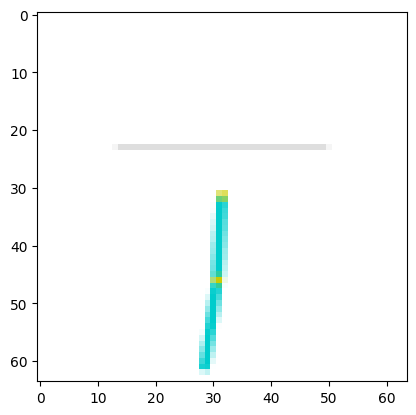

In [2]:
obs, _ = env.reset()
plt.imshow(obs[:, :, :3] / 255)

In [3]:
samples = random_sample_single_env(env, num_steps=steps)
for i in range(steps):
    buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000


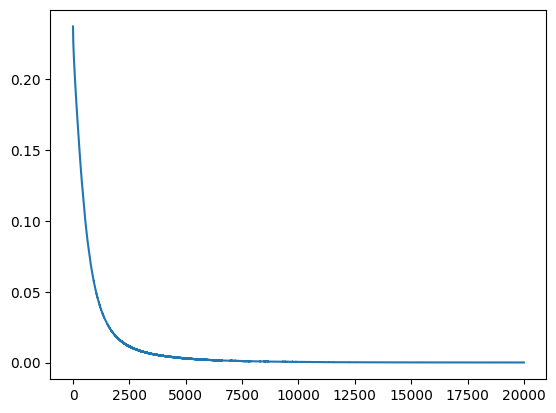

In [4]:
from fundamental_variable_discovery import Encoder, Decoder

encoder = Encoder(framestack, latent_size, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_size).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-5)

losses = []
for i in range(20000):
    if i % 1000 == 0:
        print(i)
    samples = buffer.sample(128)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255 - 0.5).cuda()
    latent = encoder(obs)
    reconstruction = decoder(latent)
    loss = torch.nn.functional.mse_loss(reconstruction, obs + 0.5)
    loss.backward()
    opt.step()
    opt.zero_grad()
    losses.append(loss.detach().cpu().numpy())
plt.plot(losses)

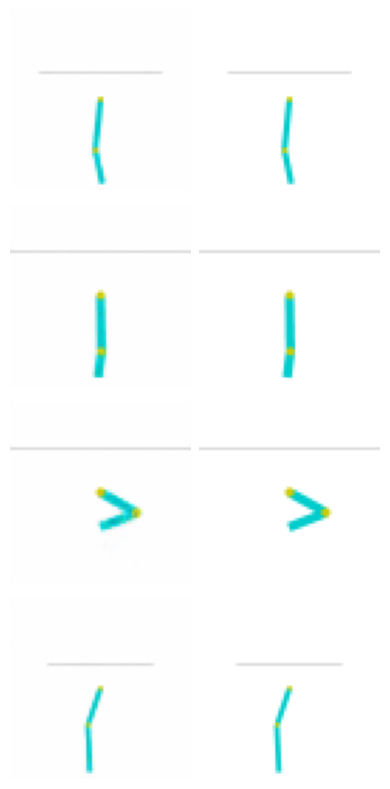

In [5]:
num_img = 4
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
for i in range(4):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()

In [6]:
latent_ID = []
image_ID = []

for _ in range(20):
    samples = buffer.sample(2048)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255 - 0.5).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")
int_dim = int(np.ceil(np.mean(latent_ID)))

Latent ID: 8.369822538636278 +- 0.09136355525279977
Image ID: 7.275121750680384 +- 0.06312873722847082


0
1000
2000
3000
4000
5000
6000
7000
8000
9000


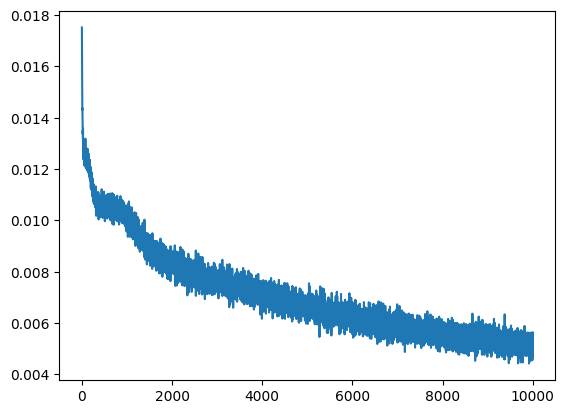

In [7]:
int_encoder = MLP(latent_size, int_dim, hidden_dim=1024).cuda()
int_decoder = MLP(int_dim, latent_size, hidden_dim=1024).cuda()
int_opt = torch.optim.Adam(list(int_encoder.parameters()) + list(int_decoder.parameters()), 3e-5)

losses = []
for i in range(10000):
    if i % 1000 == 0:
        print(i)
    samples = buffer.sample(128)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255 - 0.5).cuda()
    latent = encoder(obs).detach()
    int_ = int_encoder(latent)
    latent_reconstruction = int_decoder(int_)
    loss = torch.nn.functional.mse_loss(latent, latent_reconstruction)
    loss.backward()
    int_opt.step()
    int_opt.zero_grad()
    losses.append(loss.detach().cpu().numpy())
plt.plot(losses)

In [8]:
print(latent[0])
print(latent_reconstruction[0])

tensor([-0.0990, -0.0509, -0.0133,  ..., -0.0131, -0.1101, -0.1480],
       device='cuda:0')
tensor([-0.0636, -0.0956, -0.0158,  ...,  0.0844, -0.0683, -0.1180],
       device='cuda:0', grad_fn=<SelectBackward0>)
